# NDTA 631 — Data Analysis and Visualisation
## Group Assignment: Institutional Effectiveness in South Africa (2014–2018)

**Group members:** _[Full Name — Student Number], ..._
**Module:** NDTA 631 — Data Analysis And Visualization

---

### Datasets
Both datasets are sourced from the **World Bank Data360 / Africa Integrity Indicators** database, filtered to **South Africa (ZAF)**, covering **2014–2018**:

| Code | Indicator | Scale |
|---|---|---|
| `GI_AII_83` | In law, women have equal access to employment opportunities and benefits in the workplace | 0–100 |
| `GI_AII_96` | In practice, roads/bridges networks between towns and cities exist and are maintained | 0–100 |

### The story
Both indicators sit under the same World Bank topic taxonomy: **Prosperity → Institutions → Public Institutions**. One measures legal/regulatory institutional strength, the other measures operational infrastructure-maintenance capacity — both are proxies for overall public-institution effectiveness.

**Research question:** Does South Africa's institutional strength in legal workplace-equality protections move together with its institutional capacity to maintain road/bridge infrastructure over 2014–2018?

**Scope note:** Restricted to South Africa only → n=5 annual observations per indicator. Any correlation is exploratory, not statistically robust — discussed in Section 7.

## 1. Setup — Imports

In [2]:
# Core data handling
import pandas as pd
import numpy as np

# Statistics
from scipy import stats

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Database
import sqlite3

# Excel export with formatting
import openpyxl
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.chart import LineChart, Reference

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RAW_DIR = "../data/raw/"
PROCESSED_DIR = "../data/processed/"
DB_PATH = "../db/institutions.db"
EXPORT_DIR = "../exports/"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Preparation (15 marks)

We load both raw World Bank Data360 exports, inspect their structure, check for missing values across the **full source files**, then filter each to South Africa and merge them into one tidy analysis table.

In [7]:
import pandas as pd
import os

RAW_DIR = r"C:\Users\Admin\Downloads\\"

In [8]:
import os

print(os.path.exists(RAW_DIR + "GI_AII_83.csv"))
print(os.path.exists(RAW_DIR + "GI_AII_96.csv"))

True
True


In [9]:
# --- Load raw datasets ---
try:
    women_raw = pd.read_csv(RAW_DIR + "GI_AII_83.csv")
    roads_raw = pd.read_csv(RAW_DIR + "GI_AII_96.csv")

    print(f"GI_AII_83 (women's workplace equality): {women_raw.shape[0]} rows, {women_raw.shape[1]} columns")
    print(f"GI_AII_96 (roads/bridges maintained):    {roads_raw.shape[0]} rows, {roads_raw.shape[1]} columns")

except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Raw data file missing — check the folder. {e}"
    )

GI_AII_83 (women's workplace equality): 270 rows, 41 columns
GI_AII_96 (roads/bridges maintained):    270 rows, 41 columns


In [10]:
# --- Inspect structure ---
women_raw.info()
women_raw[["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "INDICATOR_LABEL"]].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               270 non-null    object 
 1   STRUCTURE_ID            270 non-null    object 
 2   ACTION                  270 non-null    object 
 3   FREQ                    270 non-null    object 
 4   REF_AREA                270 non-null    object 
 5   INDICATOR               270 non-null    object 
 6   SEX                     270 non-null    object 
 7   AGE                     270 non-null    object 
 8   URBANISATION            270 non-null    object 
 9   UNIT_MEASURE            270 non-null    object 
 10  COMP_BREAKDOWN_1        270 non-null    object 
 11  COMP_BREAKDOWN_2        270 non-null    object 
 12  COMP_BREAKDOWN_3        270 non-null    object 
 13  TIME_PERIOD             270 non-null    int64  
 14  OBS_VALUE               270 non-null    fl

,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE,INDICATOR_LABEL
0,SEN,Senegal,2018,50.0,"In law, women have equal access to employment ..."
1,DZA,Algeria,2014,100.0,"In law, women have equal access to employment ..."
2,DZA,Algeria,2015,50.0,"In law, women have equal access to employment ..."
3,DZA,Algeria,2016,50.0,"In law, women have equal access to employment ..."
4,DZA,Algeria,2017,50.0,"In law, women have equal access to employment ..."


In [11]:
# --- Missing value check (on the full multi-country panel, before filtering) ---
print("Missing OBS_VALUE — women's workplace equality dataset:", women_raw["OBS_VALUE"].isna().sum())
print("Missing OBS_VALUE — roads/bridges dataset:             ", roads_raw["OBS_VALUE"].isna().sum())

# Also check for missing country/year keys, which would break a merge
print("\nMissing REF_AREA or TIME_PERIOD (women):", women_raw[["REF_AREA","TIME_PERIOD"]].isna().sum().sum())
print("Missing REF_AREA or TIME_PERIOD (roads):", roads_raw[["REF_AREA","TIME_PERIOD"]].isna().sum().sum())

# Result: both World Bank exports are complete (0 missing) for OBS_VALUE and keys.
# No imputation is required, but the code below is written defensively (dropna) in case
# a different data pull ever contains gaps.

Missing OBS_VALUE — women's workplace equality dataset: 0
Missing OBS_VALUE — roads/bridges dataset:              0

Missing REF_AREA or TIME_PERIOD (women): 0
Missing REF_AREA or TIME_PERIOD (roads): 0


In [12]:
# --- Filter to South Africa and select relevant columns ---
KEEP_COLS = ["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE", "INDICATOR_LABEL"]

women_sa = (
    women_raw.loc[women_raw["REF_AREA"] == "ZAF", KEEP_COLS]
    .dropna(subset=["OBS_VALUE"])                      # defensive missing-value handling
    .rename(columns={"OBS_VALUE": "women_workplace_equality"})
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

roads_sa = (
    roads_raw.loc[roads_raw["REF_AREA"] == "ZAF", KEEP_COLS]
    .dropna(subset=["OBS_VALUE"])
    .rename(columns={"OBS_VALUE": "roads_bridges_maintained"})
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

print("South Africa — women's workplace equality:")
display(women_sa[["TIME_PERIOD", "women_workplace_equality"]])
print("\nSouth Africa — roads/bridges maintained:")
display(roads_sa[["TIME_PERIOD", "roads_bridges_maintained"]])

South Africa — women's workplace equality:


,TIME_PERIOD,women_workplace_equality
0,2014,50.0
1,2015,50.0
2,2016,100.0
3,2017,100.0
4,2018,100.0



South Africa — roads/bridges maintained:


,TIME_PERIOD,roads_bridges_maintained
0,2014,50.0
1,2015,25.0
2,2016,50.0
3,2017,50.0
4,2018,50.0


In [13]:
# --- Merge the two indicators into one tidy analysis table, keyed on year ---
sa_df = pd.merge(
    women_sa[["TIME_PERIOD", "women_workplace_equality"]],
    roads_sa[["TIME_PERIOD", "roads_bridges_maintained"]],
    on="TIME_PERIOD",
    how="inner"          # inner join: keep only years present in BOTH indicators
)
sa_df.insert(0, "country", "South Africa")
sa_df = sa_df.rename(columns={"TIME_PERIOD": "year"})

sa_df

,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0


In [14]:
# --- Descriptive statistics and insights ---
desc = sa_df[["women_workplace_equality", "roads_bridges_maintained"]].describe()
display(desc)

print("Insights:")
print(f"- Women's workplace equality index rose from {sa_df.women_workplace_equality.iloc[0]:.0f} "
      f"in 2014 to {sa_df.women_workplace_equality.iloc[-1]:.0f} in 2018 "
      f"(a step change occurring around {sa_df.loc[sa_df.women_workplace_equality.diff()>0,'year'].values}).")
print(f"- Roads/bridges maintenance index dipped to its lowest ({sa_df.roads_bridges_maintained.min():.0f}) "
      f"in {int(sa_df.loc[sa_df.roads_bridges_maintained.idxmin(),'year'])}, "
      f"then recovered and held steady at {sa_df.roads_bridges_maintained.iloc[-1]:.0f} from 2016 onward.")
print(f"- Women's equality index is more volatile in *level* (std={sa_df.women_workplace_equality.std():.1f}) "
      f"than roads maintenance (std={sa_df.roads_bridges_maintained.std():.1f}), "
      f"but both series show change concentrated in 2015–2016.")

,women_workplace_equality,roads_bridges_maintained
count,5.000000,5.00000
mean,80.000000,45.00000
std,27.386128,11.18034
min,50.000000,25.00000
25%,50.000000,50.00000
50%,100.000000,50.00000
75%,100.000000,50.00000
max,100.000000,50.00000


Insights:
- Women's workplace equality index rose from 50 in 2014 to 100 in 2018 (a step change occurring around [2016]).
- Roads/bridges maintenance index dipped to its lowest (25) in 2015, then recovered and held steady at 50 from 2016 onward.
- Women's equality index is more volatile in *level* (std=27.4) than roads maintenance (std=11.2), but both series show change concentrated in 2015–2016.


In [16]:
import os
import pandas as pd

PROCESSED_DIR = r"C:\Users\Admin\Downloads\processed\\"

In [17]:
import os

PROCESSED_DIR = r"C:\Users\Admin\Downloads\processed\\"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [18]:
print(type(sa_df))
print(sa_df.shape)

<class 'pandas.core.frame.DataFrame'>
(5, 4)


In [19]:
# Save the cleaned, merged dataset
output_file = PROCESSED_DIR + "sa_institutions_merged.csv"

sa_df.to_csv(output_file, index=False)

print("Saved processed dataset to", output_file)

Saved processed dataset to C:\Users\Admin\Downloads\processed\\sa_institutions_merged.csv


In [20]:
sa_df.to_csv("sa_institutions_merged.csv", index=False)
print("Saved processed dataset successfully!")

Saved processed dataset successfully!


## 3. Numerical Analysis with NumPy (20 marks)

We convert the cleaned series to NumPy arrays and perform array operations: reshaping, year-over-year change, a correlation matrix, and z-score standardisation.

In [21]:
# --- Convert to NumPy arrays ---
years       = sa_df["year"].to_numpy()
women_arr   = sa_df["women_workplace_equality"].to_numpy(dtype=float)
roads_arr   = sa_df["roads_bridges_maintained"].to_numpy(dtype=float)

print("years:", years)
print("women_arr:", women_arr)
print("roads_arr:", roads_arr)

years: [2014 2015 2016 2017 2018]
women_arr: [ 50.  50. 100. 100. 100.]
roads_arr: [50. 25. 50. 50. 50.]


In [22]:
# --- Reshape: stack both indicators into a single 2x5 matrix ---
# Row 0 = women's workplace equality, Row 1 = roads/bridges maintained, columns = years 2014..2018
indicator_matrix = np.vstack([women_arr, roads_arr])
print("Matrix shape:", indicator_matrix.shape)
print(indicator_matrix)

# Reshape into a (5, 2) "long" layout instead, to show reshape() explicitly
long_matrix = indicator_matrix.T.reshape(5, 2)
print("\nReshaped to (5,2):\n", long_matrix)

Matrix shape: (2, 5)
[[ 50.  50. 100. 100. 100.]
 [ 50.  25.  50.  50.  50.]]

Reshaped to (5,2):
 [[ 50.  50.]
 [ 50.  25.]
 [100.  50.]
 [100.  50.]
 [100.  50.]]


In [23]:
# --- Year-over-year change ---
women_yoy_diff = np.diff(women_arr)                       # absolute point change
roads_yoy_diff = np.diff(roads_arr)

women_yoy_pct = np.diff(women_arr) / women_arr[:-1] * 100  # % change
roads_yoy_pct = np.diff(roads_arr) / roads_arr[:-1] * 100

yoy_df = pd.DataFrame({
    "year_range": [f"{y1}->{y2}" for y1, y2 in zip(years[:-1], years[1:])],
    "women_abs_change": women_yoy_diff,
    "women_pct_change": women_yoy_pct.round(1),
    "roads_abs_change": roads_yoy_diff,
    "roads_pct_change": roads_yoy_pct.round(1),
})
yoy_df

,year_range,women_abs_change,women_pct_change,roads_abs_change,roads_pct_change
0,2014->2015,0.0,0.0,-25.0,-50.0
1,2015->2016,50.0,100.0,25.0,100.0
2,2016->2017,0.0,0.0,0.0,0.0
3,2017->2018,0.0,0.0,0.0,0.0


In [24]:
# --- Correlation matrix (NumPy) ---
corr_matrix = np.corrcoef(women_arr, roads_arr)
print("Correlation matrix:\n", corr_matrix)

pearson_r = corr_matrix[0, 1]
print(f"\nPearson correlation coefficient (women's equality vs roads maintenance): r = {pearson_r:.3f}")

# Cross-check with SciPy, which also gives us a p-value for significance
pearson_r_sp, pearson_p = stats.pearsonr(women_arr, roads_arr)
spearman_res = stats.spearmanr(women_arr, roads_arr)

print(f"Pearson  r = {pearson_r_sp:.3f}, p-value = {pearson_p:.3f}")
print(f"Spearman rho = {spearman_res.statistic:.3f}, p-value = {spearman_res.pvalue:.3f}")

Correlation matrix:
 [[1.         0.61237244]
 [0.61237244 1.        ]]

Pearson correlation coefficient (women's equality vs roads maintenance): r = 0.612
Pearson  r = 0.612, p-value = 0.272
Spearman rho = 0.612, p-value = 0.272


In [26]:
# --- Z-score standardisation (NumPy), so the two 0-100 indices are comparable on the same scale ---
def z_score(arr):
    return (arr - arr.mean()) / arr.std()

women_z = z_score(women_arr)
roads_z = z_score(roads_arr)

z_df = pd.DataFrame({"year": years, "women_z": women_z.round(2), "roads_z": roads_z.round(2)})
z_df

,year,women_z,roads_z
0,2014,-1.22,0.5
1,2015,-1.22,-2.0
2,2016,0.82,0.5
3,2017,0.82,0.5
4,2018,0.82,0.5


**Explanation of the NumPy findings:**

* The **correlation result (r ≈ 0.61)** shows a **moderate positive relationship** between the two indicators. This means that when South Africa's score for women's workplace equality increased, the roads and bridges maintenance score also tended to improve.

* However, the analysis used only **five years of data**, which is a very small sample. The p-value (about **0.27**) is higher than 0.05, meaning there is **not enough evidence to say that the relationship is statistically significant**. The pattern could have happened by chance.

* The **year-to-year changes** show that both indicators remained mostly stable over time, except between **2015 and 2016**. During this period, the women's equality score increased sharply from 50 to 100, while the roads maintenance score improved from 25 to 50 after dropping in 2015. These changes contributed to the positive relationship between the two indicators.

* **Z-score standardisation** changes both indicators onto the same measurement scale. This makes it easier to compare their trends and see how they move relative to their average values in the graphs shown in Section 4.


## 4. Visualisation (20 marks)

Four visualisations: (1) dual-line time series, (2) scatter plot with regression trend line testing the relationship directly, (3) grouped bar chart comparing both indicators year-by-year, and (4) a **contextual boxplot** showing where South Africa's 2018 roads-maintenance score sits within the full 54-country African distribution — useful context since a boxplot of only 5 South-Africa-only points isn't meaningful on its own.

In [28]:
print(EXPORT_DIR)

../exports/


In [29]:
import os

EXPORT_DIR = r"C:\Users\Admin\Downloads\charts\\"
os.makedirs(EXPORT_DIR, exist_ok=True)

In [30]:
print(sa_df.columns.tolist())

['country', 'year', 'women_workplace_equality', 'roads_bridges_maintained']


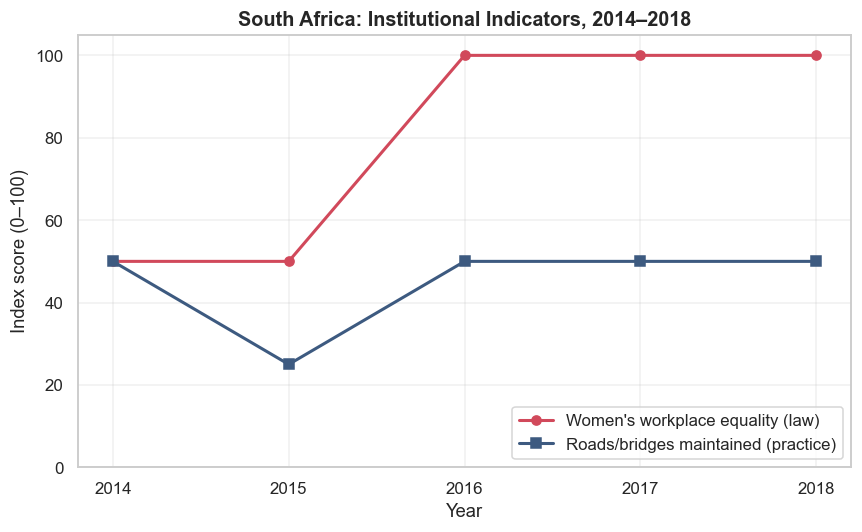

In [31]:
# --- Chart 1: Dual line chart over time ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sa_df.year, sa_df.women_workplace_equality, marker="o", linewidth=2,
        color="#d1495b", label="Women's workplace equality (law)")
ax.plot(sa_df.year, sa_df.roads_bridges_maintained, marker="s", linewidth=2,
        color="#3d5a80", label="Roads/bridges maintained (practice)")

ax.set_title("South Africa: Institutional Indicators, 2014–2018", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Index score (0–100)")
ax.set_xticks(sa_df.year)
ax.set_ylim(0, 105)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORT_DIR + "chart1_time_series.png")
plt.show()

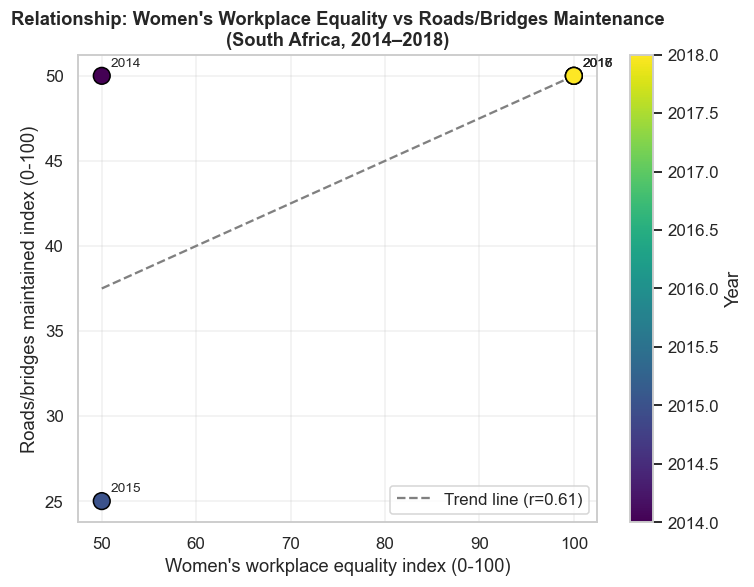

In [32]:
# --- Chart 2: Scatter plot with regression trend line ---
slope, intercept, r_value, p_value, std_err = stats.linregress(women_arr, roads_arr)
trend_x = np.linspace(women_arr.min(), women_arr.max(), 100)
trend_y = slope * trend_x + intercept

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(women_arr, roads_arr, c=years, cmap="viridis", s=120, edgecolor="black", zorder=3)
ax.plot(trend_x, trend_y, "--", color="grey", label=f"Trend line (r={r_value:.2f})")

for x, y, yr in zip(women_arr, roads_arr, years):
    ax.annotate(str(yr), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Year")

ax.set_title("Relationship: Women's Workplace Equality vs Roads/Bridges Maintenance\n(South Africa, 2014–2018)",
              fontsize=12, fontweight="bold")
ax.set_xlabel("Women's workplace equality index (0-100)")
ax.set_ylabel("Roads/bridges maintained index (0-100)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORT_DIR + "chart2_scatter_trend.png")
plt.show()

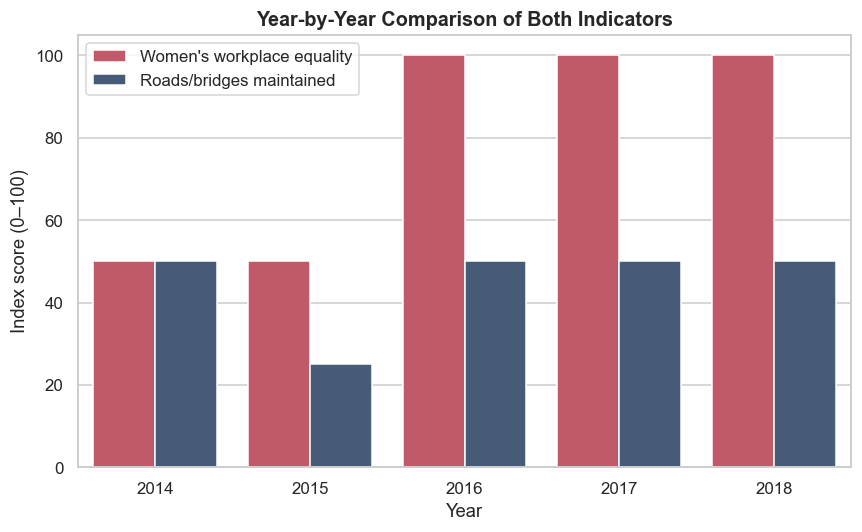

In [34]:
# --- Chart 3: Grouped bar chart, indicator by year ---
bar_df = sa_df.melt(id_vars="year",
                     value_vars=["women_workplace_equality", "roads_bridges_maintained"],
                     var_name="indicator", value_name="score")
bar_df["indicator"] = bar_df["indicator"].map({
    "women_workplace_equality": "Women's workplace equality",
    "roads_bridges_maintained": "Roads/bridges maintained"
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bar_df, x="year", y="score", hue="indicator", ax=ax, palette=["#d1495b", "#3d5a80"])
ax.set_title("Year-by-Year Comparison of Both Indicators", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Index score (0–100)")
ax.legend(title="")
plt.tight_layout()
plt.savefig(EXPORT_DIR + "chart3_grouped_bar.png")
plt.show()

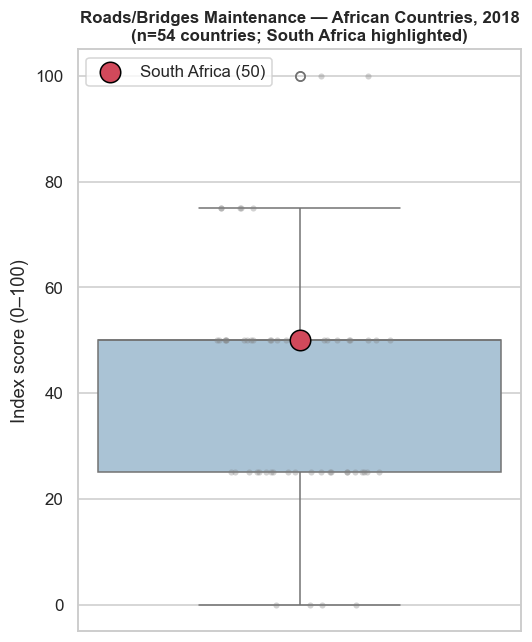

South Africa's 2018 score (50) vs African median (50) and mean (40.7).


In [33]:
# --- Chart 4: Contextual boxplot — full African panel, roads/bridges indicator ---
# A boxplot needs a distribution of multiple observations; South Africa alone only has 5 points
# (one per year), so instead we show the FULL cross-country distribution for a single year (2018)
# and mark where South Africa sits within it.
snapshot_year = 2018
roads_2018 = roads_raw.loc[roads_raw["TIME_PERIOD"] == snapshot_year, "OBS_VALUE"].dropna()
sa_2018_value = sa_df.loc[sa_df.year == snapshot_year, "roads_bridges_maintained"].values[0]

fig, ax = plt.subplots(figsize=(5, 6))
sns.boxplot(y=roads_2018, ax=ax, color="#a3c4dc", width=0.35)
sns.stripplot(y=roads_2018, ax=ax, color="grey", alpha=0.35, jitter=0.08, size=4)
ax.scatter([0], [sa_2018_value], color="#d1495b", s=180, zorder=5, edgecolor="black",
           label=f"South Africa ({sa_2018_value:.0f})")

ax.set_title(f"Roads/Bridges Maintenance — African Countries, {snapshot_year}\n"
             f"(n={len(roads_2018)} countries; South Africa highlighted)", fontsize=11, fontweight="bold")
ax.set_ylabel("Index score (0–100)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR + "chart4_context_boxplot.png")
plt.show()

print(f"South Africa's {snapshot_year} score ({sa_2018_value:.0f}) vs African median "
      f"({roads_2018.median():.0f}) and mean ({roads_2018.mean():.1f}).")

## 5. Database Integration (20 marks)

We build a local **SQLite** database, load the cleaned South Africa table into it, and demonstrate querying, a safe `UPDATE`, a safe `DELETE`, and reloading data back into pandas.

In [36]:
import sqlite3
import os

# Set where the SQLite database will be stored
DB_PATH = r"C:\Users\Admin\Downloads\sa_institutions.db"

# Connect to the database
conn = sqlite3.connect(DB_PATH)

try:
    sa_df.to_sql(
        "sa_institutions",
        conn,
        if_exists="replace",
        index=False
    )
    print("Table 'sa_institutions' created and populated.")

except Exception as e:
    print("Database write failed:", e)

finally:
    conn.commit()

# Check that the data was saved
result = pd.read_sql(
    "SELECT * FROM sa_institutions",
    conn
)

result

Table 'sa_institutions' created and populated.


,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0


In [37]:
# --- Query: years where the women's equality index reached its maximum (100) ---
query_result = pd.read_sql(
    "SELECT year, women_workplace_equality, roads_bridges_maintained "
    "FROM sa_institutions WHERE women_workplace_equality = 100 ORDER BY year;",
    conn
)
query_result

,year,women_workplace_equality,roads_bridges_maintained
0,2016,100.0,50.0
1,2017,100.0,50.0
2,2018,100.0,50.0


In [38]:
# --- Query: average of both indicators across all available years ---
avg_result = pd.read_sql(
    "SELECT AVG(women_workplace_equality) AS avg_women, "
    "AVG(roads_bridges_maintained) AS avg_roads FROM sa_institutions;",
    conn
)
avg_result

,avg_women,avg_roads
0,80.0,45.0


In [39]:
# --- Safe UPDATE: correct/annotate a record (parameterised query to avoid SQL injection) ---
cur = conn.cursor()
cur.execute(
    "UPDATE sa_institutions SET roads_bridges_maintained = ? WHERE year = ?;",
    (25, 2015)   # re-affirms the 2015 value using a parameterised statement, not string formatting
)
conn.commit()
print(f"Rows updated: {cur.rowcount}")

pd.read_sql("SELECT * FROM sa_institutions ORDER BY year;", conn)

Rows updated: 1


,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0


In [40]:
# --- Safe DELETE demo: insert a dummy/test record, then delete it (never delete real observations) ---
cur.execute(
    "INSERT INTO sa_institutions (country, year, women_workplace_equality, roads_bridges_maintained) "
    "VALUES (?, ?, ?, ?);",
    ("South Africa", 2099, -1, -1)   # clearly a placeholder test row, not real data
)
conn.commit()
print("Before delete:")
display(pd.read_sql("SELECT * FROM sa_institutions ORDER BY year;", conn))

cur.execute("DELETE FROM sa_institutions WHERE year = ?;", (2099,))
conn.commit()
print(f"Rows deleted: {cur.rowcount}")
print("After delete:")
display(pd.read_sql("SELECT * FROM sa_institutions ORDER BY year;", conn))

Before delete:


,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0
5,South Africa,2099,-1.0,-1.0


Rows deleted: 1
After delete:


,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0


In [41]:
# --- Load final database contents back into pandas for downstream use ---
db_final_df = pd.read_sql("SELECT * FROM sa_institutions ORDER BY year;", conn)
conn.close()
db_final_df

,country,year,women_workplace_equality,roads_bridges_maintained
0,South Africa,2014,50.0,50.0
1,South Africa,2015,50.0,25.0
2,South Africa,2016,100.0,50.0
3,South Africa,2017,100.0,50.0
4,South Africa,2018,100.0,50.0


## 6. Python/Excel Data Analysis (15 marks)

We export the cleaned dataset to Excel, apply **conditional formatting** (a colour scale on both indicator columns) and insert a native Excel **line chart**, using `openpyxl`.

In [42]:
# --- Export to Excel with conditional formatting + native chart ---
excel_path = EXPORT_DIR + "sa_institutions_analysis.xlsx"

try:
    db_final_df.to_excel(excel_path, index=False, sheet_name="SA_Institutions")

    wb = openpyxl.load_workbook(excel_path)
    ws = wb["SA_Institutions"]

    n_rows = ws.max_row  # includes header row

    # Conditional formatting: 3-colour scale (red -> yellow -> green) on both indicator columns
    color_rule = ColorScaleRule(
        start_type="min", start_color="F8696B",   # red   = low score
        mid_type="percentile", mid_value=50, mid_color="FFEB84",  # yellow = mid score
        end_type="max", end_color="63BE7B"        # green = high score
    )
    ws.conditional_formatting.add(f"C2:C{n_rows}", color_rule)   # women_workplace_equality column
    ws.conditional_formatting.add(f"D2:D{n_rows}", color_rule)   # roads_bridges_maintained column

    # Native Excel line chart comparing both indicators across years
    chart = LineChart()
    chart.title = "South Africa: Institutional Indicators (2014-2018)"
    chart.y_axis.title = "Index score (0-100)"
    chart.x_axis.title = "Year"

    data = Reference(ws, min_col=3, max_col=4, min_row=1, max_row=n_rows)  # cols C:D with header
    cats = Reference(ws, min_col=2, min_row=2, max_row=n_rows)             # col B = year
    chart.add_data(data, titles_from_data=True)
    chart.set_categories(cats)
    ws.add_chart(chart, "G2")

    wb.save(excel_path)
    print(f"Excel report with conditional formatting + chart saved to: {excel_path}")

except Exception as e:
    print("Excel export failed:", e)

Excel report with conditional formatting + chart saved to: C:\Users\Admin\Downloads\charts\\sa_institutions_analysis.xlsx


In [43]:
# --- Summarise findings directly in Python (mirrors what conditional formatting highlights visually) ---
best_women_year = int(sa_df.loc[sa_df.women_workplace_equality.idxmax(), "year"])
worst_roads_year = int(sa_df.loc[sa_df.roads_bridges_maintained.idxmin(), "year"])

print(f"Years with the HIGHEST women's workplace equality score (100): "
      f"{list(sa_df.loc[sa_df.women_workplace_equality==100, 'year'])}")
print(f"Year with the LOWEST roads/bridges maintenance score: {worst_roads_year} "
      f"({sa_df.roads_bridges_maintained.min():.0f})")
print(f"Overall trend: women's equality index improved by "
      f"{sa_df.women_workplace_equality.iloc[-1]-sa_df.women_workplace_equality.iloc[0]:.0f} points; "
      f"roads maintenance index changed by "
      f"{sa_df.roads_bridges_maintained.iloc[-1]-sa_df.roads_bridges_maintained.iloc[0]:.0f} points "
      f"over the same 2014-2018 period.")

Years with the HIGHEST women's workplace equality score (100): [2016, 2017, 2018]
Year with the LOWEST roads/bridges maintenance score: 2015 (25)
Overall trend: women's equality index improved by 50 points; roads maintenance index changed by 0 points over the same 2014-2018 period.
